<a href="https://colab.research.google.com/github/KadeejaHibaPT/AML_lab/blob/main/AMLlab_exp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Final Weight (w): 0.5746913334446111
Final Bias (b): 2.240509325694681
Final MSE: 0.4825353980008263


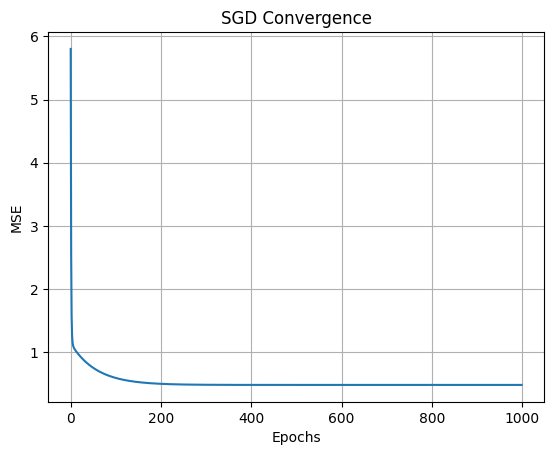

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])

# Initialize
w, b = 0, 0
lr = 0.01
epochs = 1000
mse = []

# SGD
for epoch in range(epochs):
    for i in range(len(x)):
        yp = w*x[i] + b
        error = y[i] - yp

        # Gradients
        dw = -error * x[i]
        db = -error

        # Update parameters
        w -= lr * dw
        b -= lr * db

    # MSE after each epoch
    yp = w*x + b
    loss = np.mean((y - yp)**2)
    mse.append(loss)

# Results
print("Final Weight (w):", w)
print("Final Bias (b):", b)
print("Final MSE:", mse[-1])

# Convergence plot
plt.plot(mse)
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("SGD Convergence")
plt.grid(True)
plt.show()

# New Section

Question 1: Stochastic Gradient Descent (SGD)
Problem Statement
Consider the following dataset for a simple linear regression problem:
x =[1,2,3,4,5]
y =[2,4,5,4,5]
Assume the linear regression model:
ˆ
y =wx+b
and the loss function for a single training sample:
Li = 1
2 (yi − ˆyi)2
where
ˆ
yi = wxi +b
The gradients for a single sample are:
∂Li
∂w =−(yi−ˆyi)xi

∂Li
∂b =−(yi − ˆyi)
Implement Stochastic Gradient Descent (SGD) to estimate the param
eters w and b of the linear regression model.
• Initial weight: w0 = 0
• Initial bias: b0 = 0
• Learning rate: η = 0.01
• Number of epochs: 1000
Tasks
1. Implement SGD in Python.
2. Calculate the prediction and loss for each sample.
3. Calculate the gradients of w and b.
4. Update w and b after every sample.
1
5. Calculate and store the Mean Squared Error (MSE) after every epoch.
Calculate the Mean Squared Error (MSE) after each epoch using:
MSE = 1
n
n ∑︂
i=1
(yi − ˆyi)2
6. Plot the MSE versus epochs to observe convergence.
7. Display the final values of w and b.
8. Display the final MSE.
2


Beta = 0.0
Final Weight (w): 2.000027802745835
Final Bias (b): 2.9998425357642216
Final MSE: 5.1048556573140744e-09

Beta = 0.5
Final Weight (w): 2.000000001461523
Final Bias (b): 2.999999991631034
Final MSE: 1.442592536510826e-17

Beta = 0.9
Final Weight (w): 2.0000000000000053
Final Bias (b): 2.999999999999973
Final MSE: 1.4948914153938174e-28


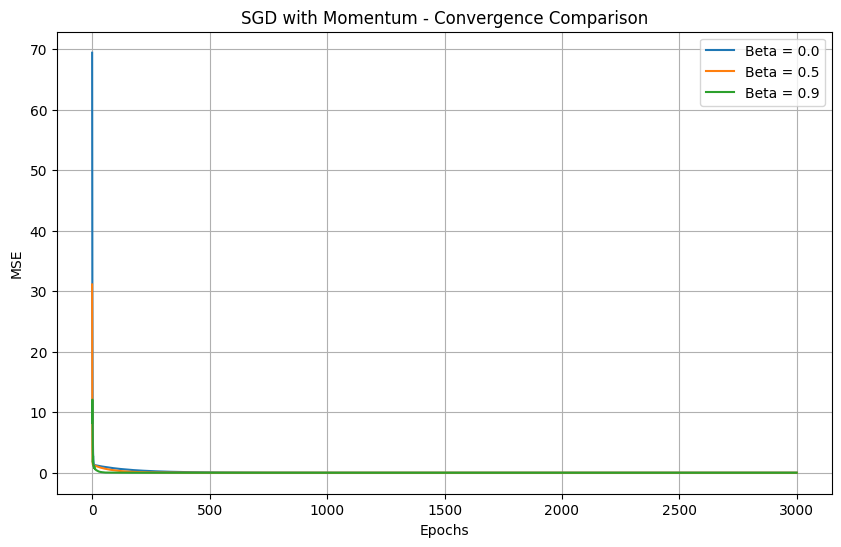

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset
X = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)
y = np.array([5, 7, 9, 11, 13, 15, 17, 19], dtype=float)

# Parameters
learning_rate = 0.001
epochs = 3000

# Momentum values to compare
betas = [0.0, 0.5, 0.9]

# Store results
results = {}

for beta in betas:

    # Initialize weight, bias and velocities
    w = 0.0
    b = 0.0
    vw = 0.0
    vb = 0.0

    mse_history = []

    # SGD with Momentum
    for epoch in range(epochs):

        # Shuffle data
        indices = np.random.permutation(len(X))

        for i in indices:

            # Select one sample
            xi = X[i]
            yi = y[i]

            # Prediction
            y_pred = w * xi + b

            # Error
            error = y_pred - yi

            # Gradients for Li = (yi - y_hat)^2
            dw = 2 * error * xi
            db = 2 * error

            # Momentum update
            vw = beta * vw + learning_rate * dw
            vb = beta * vb + learning_rate * db

            # Parameter update
            w = w - vw
            b = b - vb

        # Prediction for all samples
        y_pred_all = w * X + b

        # Calculate MSE
        mse = np.mean((y - y_pred_all) ** 2)

        # Store MSE
        mse_history.append(mse)

    # Store final results
    results[beta] = {
        "w": w,
        "b": b,
        "mse": mse,
        "history": mse_history
    }

# Display final results
for beta in betas:
    print(f"\nBeta = {beta}")
    print("Final Weight (w):", results[beta]["w"])
    print("Final Bias (b):", results[beta]["b"])
    print("Final MSE:", results[beta]["mse"])

# Plot convergence comparison
plt.figure(figsize=(10, 6))

for beta in betas:
    plt.plot(
        results[beta]["history"],
        label=f"Beta = {beta}"
    )

plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("SGD with Momentum - Convergence Comparison")
plt.legend()
plt.grid(True)
plt.show()